# IRCTC Stock Price Analysis (2019–2024)

**Goal**: To analyze historical stock prices of IRCTC, visualize trends, and generate insights using Python.

---

## Data Source & Timeframe:
- **Data Source**: IRCTC stock CSV file
- **Time Range**: 2019 to 2024
- **Key Columns Used**: `date`, `open`, `high`, `low`, `close`, `volume`

---

## Project Objectives:
- Understand how IRCTC's stock price trends over time
- Calculate key statistical measures like average, median, min, max
- Detect outliers or price anomalies
- Visualize closing prices and trading volumes
- Use a linear model to understand growth trend


## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
# Load Data
data = pd.read_csv('IRCTC_stock_data.csv')
print("file read successfully")

file read successfully


In [3]:
data.head()  # First 5 rows

,Unnamed: 0,open,high,low,close,adjclose,volume,ticker
0,2019-10-14,125.199997,148.759995,125.000000,145.550003,141.910339,226353035,IRCTC.NS
1,2019-10-15,147.199997,149.479996,139.210007,142.630005,139.063354,52650205,IRCTC.NS
2,2019-10-16,142.800003,144.199997,139.649994,140.130005,136.625870,17381530,IRCTC.NS
3,2019-10-17,140.020004,146.600006,137.429993,144.860001,141.237579,25164650,IRCTC.NS
4,2019-10-18,145.000000,157.979996,143.210007,155.830002,151.933258,48666150,IRCTC.NS


In [4]:
data.info()  # Data types & non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1125 non-null   object 
 1   open        1125 non-null   float64
 2   high        1125 non-null   float64
 3   low         1125 non-null   float64
 4   close       1125 non-null   float64
 5   adjclose    1125 non-null   float64
 6   volume      1125 non-null   int64  
 7   ticker      1125 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 70.4+ KB


In [5]:
data.describe()  # Numerical summary stats

,open,high,low,close,adjclose,volume
count,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000,1.125000e+03
mean,555.213254,563.655486,546.588177,554.734791,548.224767,7.092584e+06
std,242.690850,246.471871,238.031579,242.078944,241.379734,1.272413e+07
min,125.199997,144.199997,125.000000,140.130005,136.625870,2.809300e+05
25%,290.799988,295.790009,285.109985,289.000000,283.774902,1.576894e+06
50%,623.000000,627.650024,616.799988,622.049988,615.816101,3.059480e+06
75%,729.900024,737.599976,719.150024,725.900024,719.148560,7.002525e+06
max,1235.000000,1279.260010,1115.010010,1175.540039,1155.844849,2.263530e+08


In [6]:
data.isnull().sum() # Missing count # sum() counts how many True values

Unnamed: 0    0
open          0
high          0
low           0
close         0
adjclose      0
volume        0
ticker        0
dtype: int64

## Summary of closing prices

In [7]:
desc = data['close'].describe()
print("\n Summary of IRCTC Closing Prices:\n")
print(f" Total Records: {desc['count']}  → Total number of valid price entries")
print(f" Average Price: ₹{desc['mean']:.2f}  → Typical daily closing price")
print(f" Price Fluctuation: ₹{desc['std']:.2f}  → How much the price moves on average")
print(f" Lowest Price: ₹{desc['min']:.2f}  → Minimum price recorded")
print(f" 25% of Days Below: ₹{desc['25%']:.2f}  → Price was lower than this 25% of the time")
print(f" Median Price: ₹{desc['50%']:.2f}  → Middle value (better than average for skewed data)")
print(f" 75% of Days Below: ₹{desc['75%']:.2f}  → Price was lower than this 75% of the time")
print(f" Highest Price: ₹{desc['max']:.2f}  → Maximum price recorded")


 Summary of IRCTC Closing Prices:

 Total Records: 1125.0  → Total number of valid price entries
 Average Price: ₹554.73  → Typical daily closing price
 Price Fluctuation: ₹242.08  → How much the price moves on average
 Lowest Price: ₹140.13  → Minimum price recorded
 25% of Days Below: ₹289.00  → Price was lower than this 25% of the time
 Median Price: ₹622.05  → Middle value (better than average for skewed data)
 75% of Days Below: ₹725.90  → Price was lower than this 75% of the time
 Highest Price: ₹1175.54  → Maximum price recorded


## Key Insights / Conclusion (Descriptive Statistics)

- IRCTC's stock has shown a general upward trend over the years with some volatility.
- The **median closing price** is ₹622.05, which is higher than the average—indicating positively skewed price distribution.
- The **maximum closing price** reached ₹1175.54, while the lowest was ₹140.13.
- Standard deviation of ₹242.08 shows significant fluctuations.

## Box Plot - Detect Outliers in Closing Prices

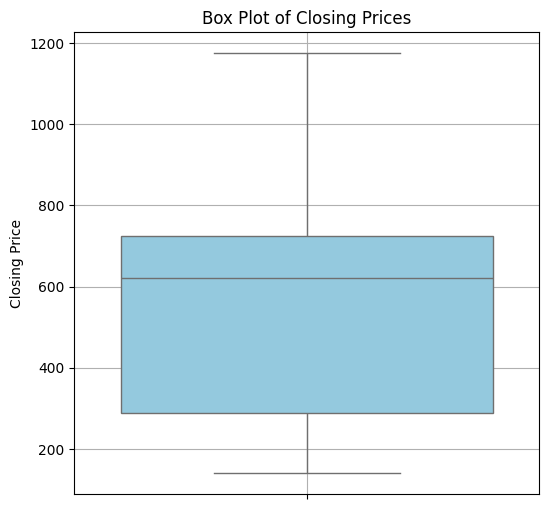

In [8]:
# This sets the size of the figure (chart) to 6x6 inches.
# A square figure is good for balanced plots like box plots
# This draws a box plot using the close column from your dataset.


plt.figure(figsize=(6, 6))
sns.boxplot(y=data['close'], color='skyblue')
plt.title('Box Plot of Closing Prices')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

#### Median value (line in the box)
#### Price range (box)
#### Outliers (dots outside box)

## Histogram for closing price distribution

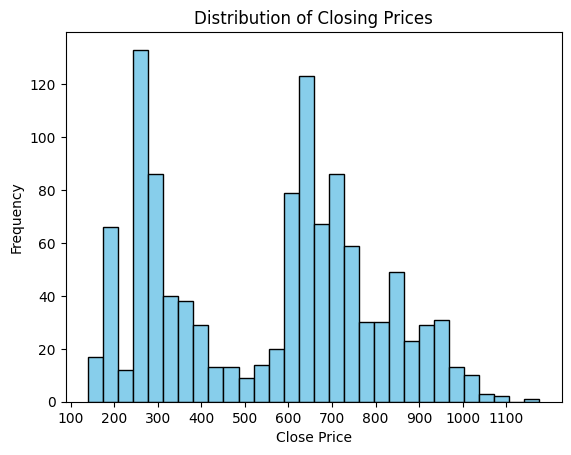

In [9]:
plt.hist(data['close'], bins=30, color='skyblue', edgecolor='black')     # Bins are intervals (or ranges) that group your data.
plt.title('Distribution of Closing Prices')
plt.xlabel('Close Price')                                                # The X-axis = price range
plt.xticks(np.arange(100, 1200, 100))                                    # Increase x-axis numbers
plt.ylabel('Frequency')                                                  # The Y-axis = number of days (frequency)
plt.show()

###  Distribution of Closing Prices

This chart shows how many days the IRCTC stock closed in different price ranges.

- **Taller bars** = More days the stock closed in that price range  
- **Shorter bars** = Fewer days at that price  
- Helps to see which prices were **most common**  

This helps us understand where the stock price usually stayed and when it was too high or too low

##  Heatmap of Correlation Between Features

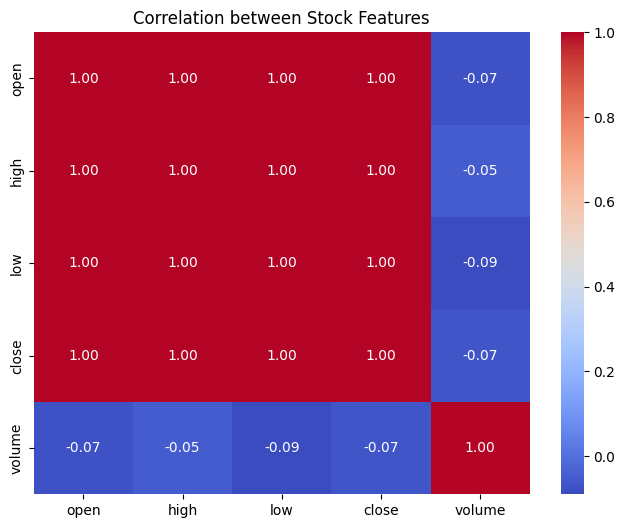

In [10]:
# Select numeric columns only
correlation = data[['open', 'high', 'low', 'close', 'volume']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation between Stock Features")
plt.show()

### Heatmap – Correlation Between Features

We check how closely related different features are:
- e.g., close vs high, open vs volume
- Darker color = stronger correlation


# Data Preprocessing

In [11]:
# Preprocessing
data.columns = [col.lower() for col in data.columns]

# Rename 'unnamed: 0' to 'date'
if 'date' not in data.columns:
    if 'unnamed: 0' in data.columns:
        data.rename(columns={'unnamed: 0': 'date'}, inplace=True)

data['date'] = pd.to_datetime(data['date'], errors='coerce')
data = data.dropna(subset=['date'])
data = data.drop_duplicates()
data = data.sort_values('date').reset_index(drop=True)
print("Final shape after preprocessing:", data.shape)
print("Date range:", data['date'].min(), "to", data['date'].max())

Final shape after preprocessing: (1125, 8)
Date range: 2019-10-14 00:00:00 to 2024-04-29 00:00:00




- All column names were converted to lowercase for consistency.
- If the date column was unnamed (e.g., `"Unnamed: 0"`), it was renamed to `"date"` for clarity.
- The `"date"` column was converted into a proper datetime format.
- Any rows with missing or invalid dates were removed to ensure time-based accuracy.
- Duplicate records were dropped to prevent redundancy in analysis.
- The dataset was sorted chronologically based on the date.
- The index was reset after sorting to maintain a clean tabular structure.

In [12]:
# Fill missing numerical data with forward then backward fill
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
data[num_cols] = data[num_cols].ffill().bfill()

###  Missing Value Treatment (Numerical Columns)

- Selected all numeric columns from the dataset.
- Applied forward fill (`ffill`) to handle missing values using previous valid entries.
- Applied backward fill (`bfill`) to handle any remaining missing values using next valid entries.
- Ensured that **all numerical columns are fully filled**, avoiding data loss and errors during analysis.

- This approach maintains trend continuity while preserving data accuracy.


In [13]:
# Feature
data['day'] = np.arange(len(data))  # numeric day index
data['sma_20'] = data['close'].rolling(window=20).mean()  # 20-day SMA
data['sma_50'] = data['close'].rolling(window=50).mean()  # 50-day SMA

### Feature Engineering

- **Day Index**: Created a numeric `day` column to represent the time progression in the dataset.
- **20-Day SMA**: Added a `sma_20` column representing the 20-day Simple Moving Average of closing prices.
- This helps identify short-term trends.
- **50-Day SMA**: Added a `sma_50` column for the 50-day Simple Moving Average to capture longer-term trends.

 These features are commonly used in stock analysis to detect price momentum, trend reversals, and support/resistance levels.


## Visualizing Closing Price with SMA 20 & 50

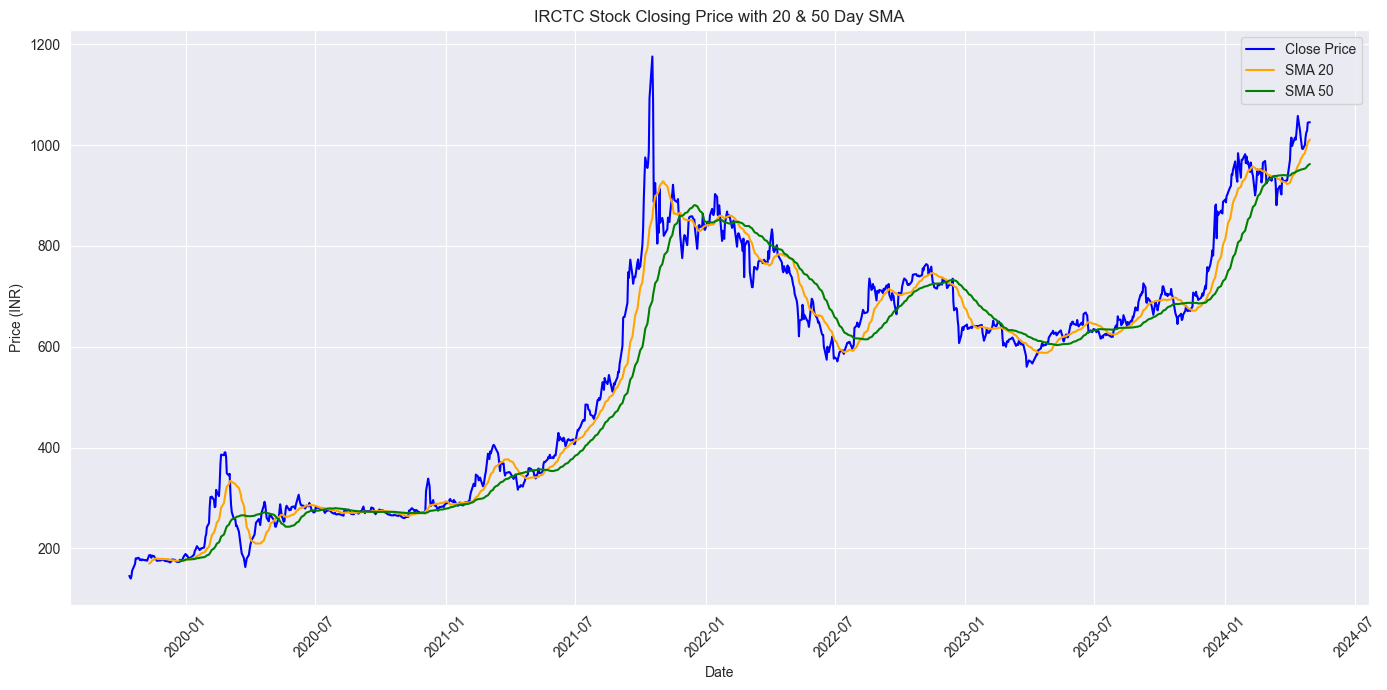

In [14]:
# Visualization
sns.set_style('darkgrid')                                                         # Sets a clean, professional background for better readability
plt.figure(figsize=(14,7))                                                        # Creates a large, widescreen plot layout for clear viewing
plt.plot(data['date'], data['close'], label='Close Price', color='blue')  
                                                                                 # Plots the actual IRCTC stock closing price over time in blue
plt.plot(data['date'], data['sma_20'], label='SMA 20', color='orange')    
                                                                                 # Adds the 20-day Simple Moving Average (short-term trend) in orange
plt.plot(data['date'], data['sma_50'], label='SMA 50', color='green')     
# Adds the 50-day Simple Moving Average (long-term trend) in green

plt.title('IRCTC Stock Closing Price with 20 & 50 Day SMA')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### This chart shows how IRCTC stock prices are moving over time
#### The two extra lines (SMA 20 and SMA 50) help us identify short-term and long-term trends
#### It’s a useful tool for understanding price momentum and support/resistance levels

## Bar Chart – Average Monthly Closing Price

C:\Users\91880\AppData\Local\Temp\ipykernel_18668\3619451186.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='close', data=monthly_avg, palette='viridis')


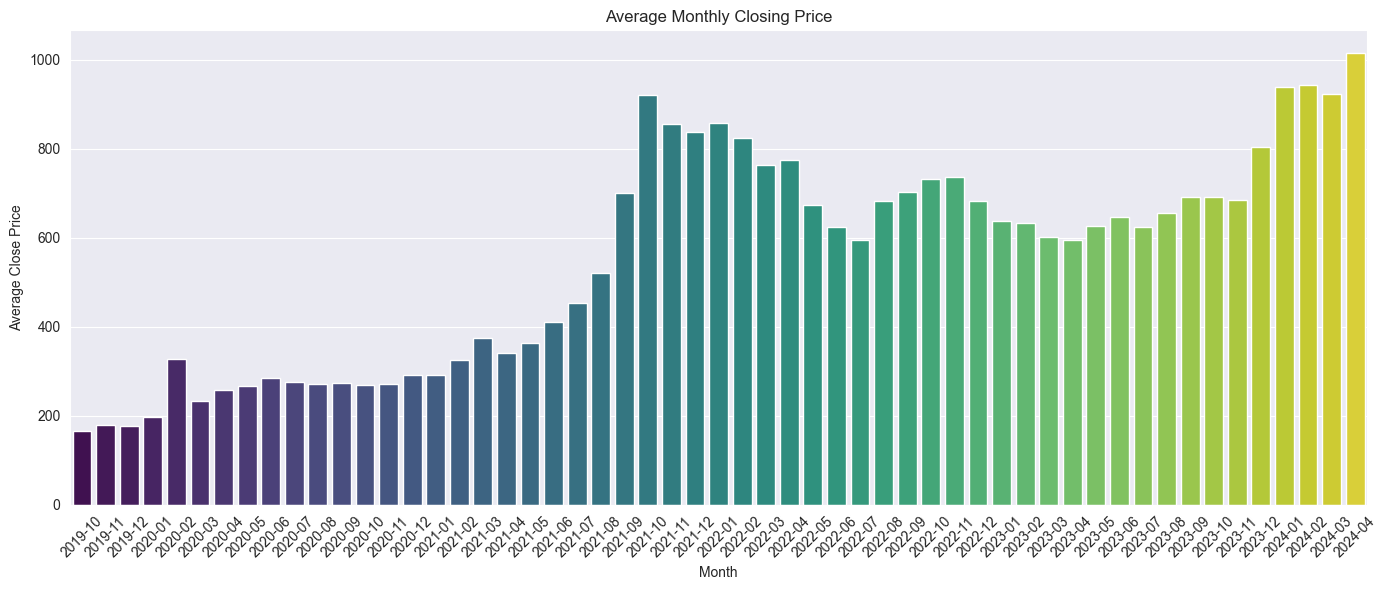

In [15]:
data['month'] = data['date'].dt.to_period('M')  # Month grouping
monthly_avg = data.groupby('month')['close'].mean().reset_index()
monthly_avg['month'] = monthly_avg['month'].astype(str)

plt.figure(figsize=(14, 6))
sns.barplot(x='month', y='close', data=monthly_avg, palette='viridis')
plt.title('Average Monthly Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Close Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Monthly Average Closing Price Analysis

- Extracted the **month** from the `date` column to group data month-wise.
- Calculated the **average closing price** for each month using `groupby`.
- Converted the month to string format for clear labeling.
- Created a **bar plot** to visualize monthly trends in closing prices.
- Rotated x-axis labels for better readability.
- This chart helps in identifying months with **strong or weak stock performance**, useful for seasonal insights or trend patterns.


## Prescriptive Signal based on SMA

In [16]:
latest = data.iloc[-1]
if latest['sma_20'] > latest['sma_50']:
    print("\nSignal: Bullish (Consider Buying)")
else:
    print("\nSignal: Bearish (Consider Selling)")


Signal: Bullish (Consider Buying)


#### SMA-Based Trading Signal

- Compared the latest 20-day and 50-day Simple Moving Averages (SMA).
- If **SMA-20 > SMA-50**, the trend is **Bullish** → Suggests a **Buy** signal.
- If **SMA-20 < SMA-50**, the trend is **Bearish** → Suggests a **Sell** signal.
- Helps guide short-term investment decisions based on trend momentum.


In [17]:
# ================= FIXED: Use only PAST information (no data leakage) ================= #

data['prev_close'] = data['close'].shift(1)
data['prev_volume'] = data['volume'].shift(1)
data['prev_sma_20'] = data['sma_20'].shift(1)
data['prev_sma_50'] = data['sma_50'].shift(1)

features = ['prev_close', 'prev_volume', 'prev_sma_20', 'prev_sma_50']

data_model = data.dropna(subset=features + ['close']).reset_index(drop=True)

X = data_model[features]
y = data_model['close']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1075, 4)
y shape: (1075,)


In [18]:
from sklearn.model_selection import train_test_split

# shuffle=False is critical for time series — order maintain rehta hai
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 860
Test size: 215


In [19]:
model_improved = LinearRegression()
model_improved.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

predictions = model_improved.predict(X_test)

r2 = r2_score(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R² Score: 0.9865
RMSE: 16.3033
MAE: 10.7941


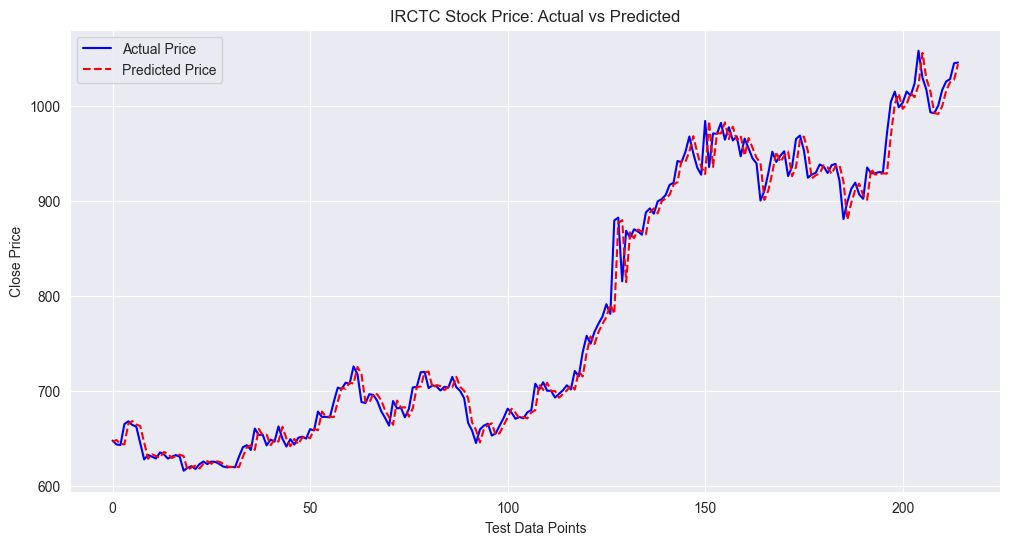

In [21]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')
plt.title('IRCTC Stock Price: Actual vs Predicted')
plt.xlabel('Test Data Points')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## IRCTC Stock Price Analysis – Summary

## Project Goal
#### The goal of this project was to analyze IRCTC’s daily closing stock prices over time, identify trends, and uncover meaningful patterns using 

#### descriptive statistics and visualizations.


## Data Source & Timeframe
#### Data Source: CSV file of IRCTC daily stock prices

#### Column of Interest: close (daily closing price)

#### Timeframe: Historical daily data over several years (Exact range based on your dataset)


## Key Questions Explored What is the average and median stock price of IRCTC?

#### 1. How much does the stock price typically fluctuate?

#### 2. Are there any outliers in price behavior?

#### 3.How has the price trended over time?

#### 4.What does the price distribution look like?

## Data Cleaning Summary
#### Removed missing/null values in the close column to ensure accurate statistical calculations and plotting.

#### Checked and confirmed date was correctly formatted for time-series plots.


## Visual Analysis Highlights
#### Line Plot: Shows the overall trend of IRCTC closing prices over time — upward spikes and dips visible clearly.

#### Box Plot: Helped detect outliers and showed the spread of prices — including median and quartiles.

#### Bar Plot: Grouped daily prices by frequency for easy understanding of distribution and common price ranges.


## Descriptive Statistics Summary
#### Total Records: 1125 valid price entries

#### Average Price: ₹554.73

#### Median Price: ₹622.05 (suggests right-skewed distribution)

#### Price Fluctuation (Std Dev): ₹242.08

#### Lowest Price: ₹140.13

#### Highest Price: ₹1175.54


## Key Insights
#### The stock price has shown significant growth, with a large gap between the lowest and highest values.

#### The median price being higher than the mean indicates positive skew, where more days had lower prices, but occasional high spikes increased the average.

#### Outliers detected by box plot suggest sudden price surges, possibly due to announcements or market events.

#### Most prices are clustered between ₹300 and ₹700, as seen in histogram and box plot.


## Limitations / Future Scope
#### This analysis focuses only on closing prices — volume, open, high, low, and financial news were not included.

#### Future work can include predictive modeling (like Linear Regression) to forecast future prices.

#### External factors (market news, economy) could be added to enrich insights.